Loading dataset...
Preprocessing complete!
Training XGBoost model...
Training complete!

XGBoost Model Evaluation:

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.81      0.84      4673
           1       0.47      0.61      0.53      1327

    accuracy                           0.76      6000
   macro avg       0.68      0.71      0.69      6000
weighted avg       0.79      0.76      0.77      6000

ROC-AUC Score: 0.7731

Confusion Matrix Business Breakdown:
True Negatives (Correctly Approved): 3775
False Positives (Incorrectly Denied - Lost Revenue): 898
False Negatives (Incorrectly Approved - Financial Loss): 523
True Positives (Correctly Denied - Risk Avoided): 804

Calculating SHAP values... (this might take a few seconds)

Training the Explainable Boosting Machine (EBM)...
EBM Training complete!

EBM Model Evaluation:

Classification Report:
              precision    recall  f1-score   support

           0       0.84

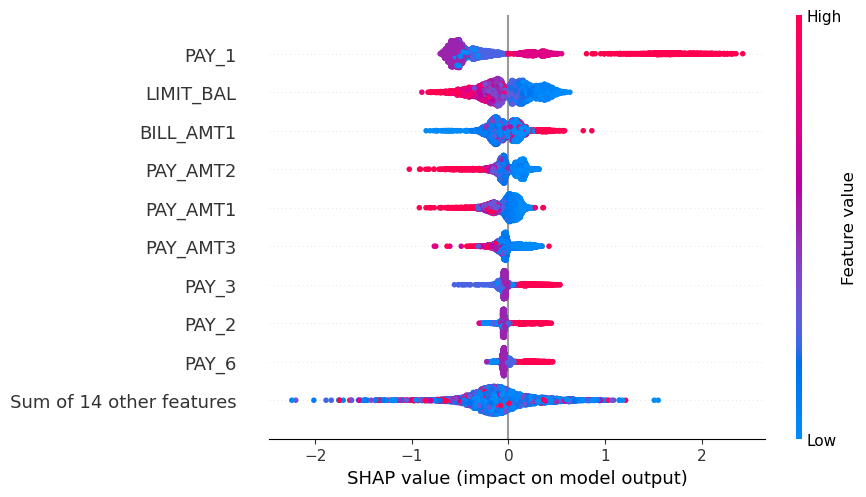


Generating XGBoost local explanation for a specific denied customer...
Generating XGBoost local explanation for customer ID: 3561


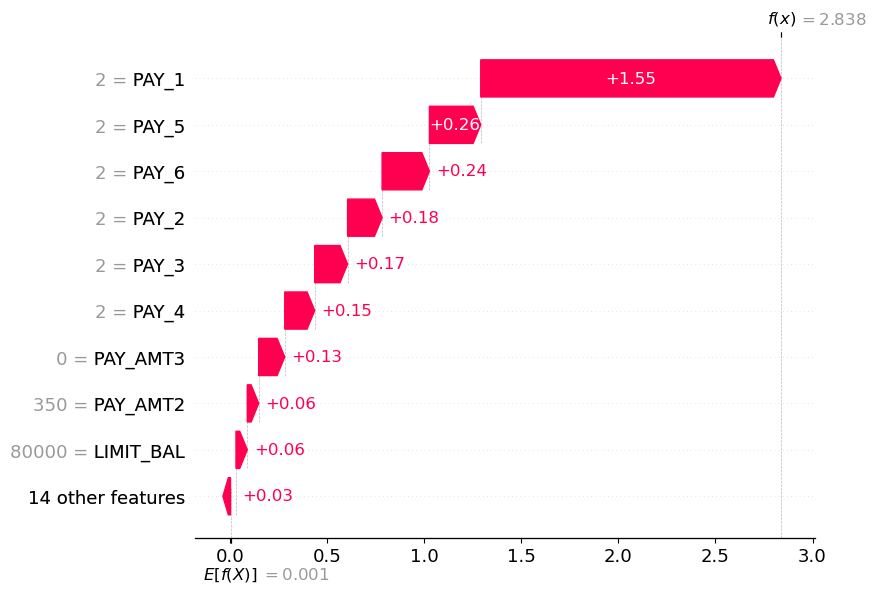


Generating EBM global explanation...
Generating EBM local explanation for customer ID: 3561


<!-- http://127.0.0.1:7001/13445306752/ -->
 Open in new window

In [2]:
import shap
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
from interpret import show
from interpret.glassbox import ExplainableBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# Load data from CSV
print("Loading dataset...")
df = pd.read_csv('UCI_Credit_Card.csv', index_col=0)

# Clean up ghost categories
df['EDUCATION'] = df['EDUCATION'].replace({0: 4, 5: 4, 6: 4})
df['MARRIAGE'] = df['MARRIAGE'].replace({0: 3})

# Rename columns
df = df.rename(columns={
    'PAY_0': 'PAY_1',
    'default.payment.next.month': 'DEFAULT'
})

# Change data type for categories
cat_cols = ['SEX', 'EDUCATION', 'MARRIAGE', 'PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

for col in cat_cols:
    df[col] = df[col].astype('category')

# Separate features from target to be predicted
X = df.drop('DEFAULT', axis=1)
y = df['DEFAULT']

# Perform stratified test/train split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Calculate scale_pos_weight for XGBoost model
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight_value = neg_count / pos_count

print("Preprocessing complete!")

# Initialize XGBoost model
xgb_model = xgb.XGBClassifier(
    scale_pos_weight=scale_pos_weight_value,
    enable_categorical=True,
    tree_method='hist',
    random_state=42,
    max_depth=5,
    learning_rate=0.1,
    n_estimators=100
)

print("Training XGBoost model...")

xgb_model.fit(X_train, y_train)

print("Training complete!")

# Make predictions
y_pred = xgb_model.predict(X_test)
y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]

# Evaluate the model for business value
print("\nXGBoost Model Evaluation:")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

auc_score = roc_auc_score(y_test, y_pred_proba)
print(f"ROC-AUC Score: {auc_score:.4f}")

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix Business Breakdown:")
print(f"True Negatives (Correctly Approved): {cm[0][0]}")
print(f"False Positives (Incorrectly Denied - Lost Revenue): {cm[0][1]}")
print(f"False Negatives (Incorrectly Approved - Financial Loss): {cm[1][0]}")
print(f"True Positives (Correctly Denied - Risk Avoided): {cm[1][1]}")

# Initialize SHAP explainer
explainer = shap.TreeExplainer(xgb_model)

# Calculate SHAP values
print("\nCalculating SHAP values... (this might take a few seconds)")
shap_values = explainer(X_test)

# Initialize and train EBM
print("\nTraining the Explainable Boosting Machine (EBM)...")

ebm_model = ExplainableBoostingClassifier(random_state=42)
ebm_model.fit(X_train, y_train)

print("EBM Training complete!")

# Evaluate EBM performance
ebm_y_pred = ebm_model.predict(X_test)
ebm_y_pred_proba = ebm_model.predict_proba(X_test)[:,1]

print("\nEBM Model Evaluation:")
print("\nClassification Report:")
print(classification_report(y_test, ebm_y_pred))

ebm_auc_score = roc_auc_score(y_test, ebm_y_pred_proba)
print(f"ROC-AUC Score: {ebm_auc_score:.4f}")

print("\n===================================")

# Generate XGBoost global explanation
print("\nGenerating XGBoost global explanation...")
plt.figure(figsize=(10, 6))
shap.plots.beeswarm(shap_values, max_display=10)

# Generate XGBoost local explanation
print("\nGenerating XGBoost local explanation for a specific denied customer...")
true_positive = (y_test == 1) & (y_pred == 1) & (ebm_y_pred == 1)
ex_customer_idx = np.where(true_positive)[0][0]
customer_id = X_test.index[ex_customer_idx]

print(f"Generating XGBoost local explanation for customer ID: {customer_id}")
plt.figure(figsize=(8, 5))
shap.plots.waterfall(shap_values[ex_customer_idx])

# Generate EBM global explanation
print("\nGenerating EBM global explanation...")
ebm_global = ebm_model.explain_global(name='EBM Global')

# Generate EBM local explanation
print(f"Generating EBM local explanation for customer ID: {customer_id}")
ebm_local = ebm_model.explain_local(
    X_test.iloc[[ex_customer_idx]], 
    y_test.iloc[[ex_customer_idx]], 
    name='EBM Local'
)

show([ebm_global, ebm_local])


In [3]:
import joblib

# Save the trained XGBoost model
joblib.dump(xgb_model, 'xgb_model.joblib')

# Save the SHAP Explainer
joblib.dump(explainer, 'shap_explainer.joblib')

print("Models successfully saved to disk!")

Models successfully saved to disk!


During my testing, I found that post-hoc explainers like SHAP and inherently interpretable models like EBMs don't always agree on the same threshold for edge-case customers. It proved to me that you cannot just blindly trust a single explanation layer; you have to look at the raw probabilities and understand the model's architecture.